In [17]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot


In [4]:
os.getcwd()
os.chdir(r'E:\01_PROJECTS\01_Roads')
os.getcwd()

'E:\\01_PROJECTS\\01_Roads'

In [7]:
current_roads = gpd.read_file(r'02_vectors\01_NTD_lines\merged_ntd_roads.shp')
print(current_roads.head())

                             permanent_    source_fea  \
0  cdda0d86-7780-4d5e-a3f5-997bf2ea4a41  110431699226   
1  353f71b8-97df-4d9f-a0c7-72d9d1ba971f  110431687347   
2  8a8d449f-c773-49b0-80b4-b8ca9bd22042  110431687445   
3  760d227b-c5d2-4471-8ce0-f01c9908f009  110431698153   
4  4a161351-9783-402a-ad1c-c2de7c8ea96b  110431686659   

                               source_dat                          source_d_1  \
0  {E03189CA-63E4-49E2-AB91-A0963EDE6195}                   NPS Roads 12/2021   
1                                    None  2014 Tiger/Line Shapefiles Release   
2                                    None  2014 Tiger/Line Shapefiles Release   
3                                    None  2014 Tiger/Line Shapefiles Release   
4                                    None  2014 Tiger/Line Shapefiles Release   

                                          source_ori   loaddate interstate  \
0                              National Park Service 2022-09-01       None   
1  U.S. Depart

In [9]:
old_roads = gpd.read_file(r'02_vectors\tiger2k\merged_2k_roads.shp')
print(old_roads.head())

     MODULE      TLID  SIDE1 SOURCE FEDIRP             FENAME FETYPE FEDIRS  \
0  TGR54001  53169896    NaN      B   None    County Route 54   None   None   
1  TGR54001  53169897    NaN      B   None  County Route 17/6   None   None   
2  TGR54001  53169898    NaN      J   None    County Route 54   None   None   
3  TGR54001  53169899    NaN      J   None        Perry Goode     Rd   None   
4  TGR54001  53169900    NaN      B   None            Talbott     Rd   None   

  CFCC FRADDL  ... BLK90R AIRL AIRR  ANRCL  ANRCR  AITSCEL  AITSCER  AITSL  \
0  A41   None  ...    436  NaN  NaN    NaN    NaN      NaN      NaN    NaN   
1  A41   None  ...    445  NaN  NaN    NaN    NaN      NaN      NaN    NaN   
2  A41   None  ...    436  NaN  NaN    NaN    NaN      NaN      NaN    NaN   
3  A41   None  ...    436  NaN  NaN    NaN    NaN      NaN      NaN    NaN   
4  A41   None  ...    442  NaN  NaN    NaN    NaN      NaN      NaN    NaN   

   AITSR                                           geome

In [39]:
counties = gpd.read_file(r'02_vectors\tl_2024_us_county.shp')
alb_county = counties[counties['STATEFP'] == '51']
alb_county = counties[counties['NAME'] == 'Albemarle']

<Axes: >

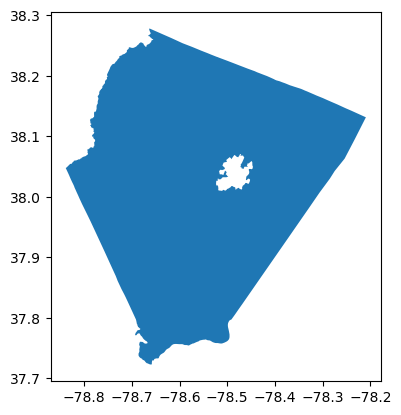

In [41]:
alb_county.plot()

In [42]:
alb_current = current_roads.clip(alb_county)
alb_old = old_roads.clip(alb_county)

c:\Program Files\KNIME\bundling\envs\sdl_harvard_geospatial\lib\site-packages\geopandas\tools\clip.py:67: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


<Axes: >

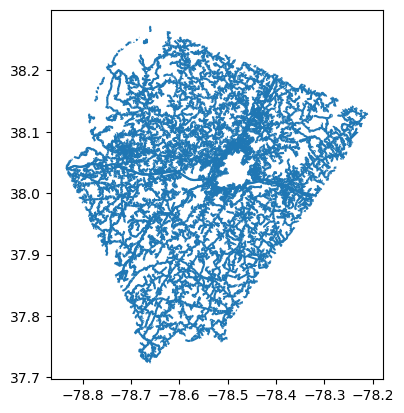

In [44]:
alb_current.plot()

<Axes: >

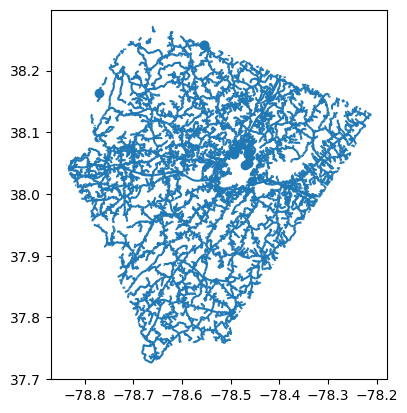

In [45]:
alb_old.plot()

In [51]:
alb_current.to_file(r'E:\01_PROJECTS\01_Roads\01_scripts\snapping_roads\alb_current_roads.shp')

c:\Program Files\KNIME\bundling\envs\sdl_harvard_geospatial\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field loaddate create as date field, though DateTime requested.
  ogr_write(


In [ ]:
# Check what geometry types you have
print("Geometry types in alb_old:")
print(alb_old.geometry.geom_type.value_counts())

# Filter to keep only linestrings if you have mixed types
linestrings_only = alb_old[alb_old.geometry.geom_type == 'LineString']
linestrings_only.to_file(r'E:\01_PROJECTS\01_Roads\01_scripts\snapping_roads\alb_old_roads.shp', 
                        driver='Esri Shapefile')

Geometry types in alb_old:
LineString            14368
MultiLineString          21
Point                     9
GeometryCollection        2
dtype: int64


In [ ]:


############# THIS IS OUR BEST OPTION RIGHT NOW




from shapely.geometry import LineString, Point
from shapely.ops import nearest_points
import geopandas as gpd
import numpy as np
from scipy.spatial import cKDTree



# Parameters
dist_tol = 20  # meters
angle_tol = 20  # degrees

# Input GeoDataFrames
old = alb_old
new = alb_current

# Project to EPSG:5070 (NAD83 / Conus Albers)
old = old.to_crs(epsg=5070)
new = new.to_crs(epsg=5070)

# Explode into individual LineStrings
old = old.explode(index_parts=False).reset_index(drop=True)
new = new.explode(index_parts=False).reset_index(drop=True)

# Build spatial index from centroids of new roads
new['centroid'] = new.geometry.centroid
new_tree = cKDTree(np.vstack(new['centroid'].apply(lambda p: (p.x, p.y))))

# Helper to compute angle of a line
def line_angle(geom):
    coords = list(geom.coords)
    if len(coords) >= 2:
        dx = coords[-1][0] - coords[0][0]
        dy = coords[-1][1] - coords[0][1]
        return np.degrees(np.arctan2(dy, dx)) % 180
    return None

# Snap old segment to best-matching new road segment, if within tolerance
snapped_geoms = []
was_snapped = []

for i, row in old.iterrows():
    old_geom = row.geometry
    old_angle = line_angle(old_geom)
    if old_angle is None:
        snapped_geoms.append(old_geom)
        was_snapped.append(False)
        continue

    # Query nearest roads in 2023 dataset
    centroid = old_geom.centroid
    _, idxs = new_tree.query([(centroid.x, centroid.y)], k=5, distance_upper_bound=dist_tol)
    idxs = idxs[0]  # Flatten result

    best_match = None
    best_distance = np.inf

    for idx in idxs:
        if idx >= len(new):  # out-of-bounds (no match)
            continue
        candidate_geom = new.iloc[idx].geometry
        candidate_angle = line_angle(candidate_geom)
        if candidate_angle is None:
            continue

        angle_diff = abs(old_angle - candidate_angle)
        angle_diff = min(angle_diff, 180 - angle_diff)

        if angle_diff <= angle_tol:
            dist = old_geom.distance(candidate_geom)
            if dist < best_distance:
                best_match = candidate_geom
                best_distance = dist

    if best_match:
        # Snap: preserve geometry, but align with new
        snapped_geoms.append(best_match)
        was_snapped.append(True)
    else:
        # Keep original geometry
        snapped_geoms.append(old_geom)
        was_snapped.append(False)

# Output
old['geometry'] = snapped_geoms
old['was_snapped'] = was_snapped


In [ ]:


### TESTING 1

from shapely.geometry import LineString, Point
from shapely.ops import nearest_points
import geopandas as gpd
import numpy as np
from scipy.spatial import cKDTree

# Parameters
dist_tol = 20  # meters
angle_tol = 20  # degrees

# Input GeoDataFrames
old = alb_old
new = alb_current

# Project to EPSG:5070 (NAD83 / Conus Albers)
old = old.to_crs(epsg=5070)
new = new.to_crs(epsg=5070)

# Explode into individual LineStrings
old = old.explode(index_parts=False).reset_index(drop=True)
new = new.explode(index_parts=False).reset_index(drop=True)

# Build spatial index from centroids of new roads
new['centroid'] = new.geometry.centroid
new_tree = cKDTree(np.vstack(new['centroid'].apply(lambda p: (p.x, p.y))))

# Helper to compute angle of a line
def line_angle(geom):
    coords = list(geom.coords)
    if len(coords) >= 2:
        dx = coords[-1][0] - coords[0][0]
        dy = coords[-1][1] - coords[0][1]
        return np.degrees(np.arctan2(dy, dx)) % 180
    return None

# Snap old segment to best-matching new road segment, if within tolerance
snapped_geoms = []
was_snapped = []

for i, row in old.iterrows():
    old_geom = row.geometry
    old_angle = line_angle(old_geom)
    if old_angle is None:
        snapped_geoms.append(old_geom)
        was_snapped.append(False)
        continue

    centroid = old_geom.centroid
    distances, idxs = new_tree.query([(centroid.x, centroid.y)], k=5, distance_upper_bound=dist_tol)
    distances = distances[0]
    idxs = idxs[0]

    valid_candidates = [
        (idx, dist) for idx, dist in zip(idxs, distances)
        if idx < len(new) and np.isfinite(dist)
    ]

    best_match = None
    best_distance = np.inf

    for idx, dist in valid_candidates:
        candidate_geom = new.iloc[idx].geometry
        candidate_angle = line_angle(candidate_geom)
        if candidate_angle is None:
            continue

        angle_diff = abs(old_angle - candidate_angle)
        angle_diff = min(angle_diff, 180 - angle_diff)

        if angle_diff <= angle_tol and dist < best_distance:
            best_match = candidate_geom
            best_distance = dist

    if best_match:
        snapped_geoms.append(best_match)
        was_snapped.append(True)
    else:
        # Keep original geometry
        snapped_geoms.append(old_geom)
        was_snapped.append(False)


# Output
old['geometry'] = snapped_geoms
old['was_snapped'] = was_snapped


In [75]:


### TESTING 2

from shapely.geometry import LineString, Point
from shapely.ops import nearest_points
import geopandas as gpd
import numpy as np
from scipy.spatial import cKDTree

# Parameters
dist_tol = 20  # meters
angle_tol = 20  # degrees

# Input GeoDataFrames
old = alb_old
new = alb_current

# Project to EPSG:5070 (NAD83 / Conus Albers)
old = old.to_crs(epsg=5070)
new = new.to_crs(epsg=5070)

# Explode into individual LineStrings
old = old.explode(index_parts=False).reset_index(drop=True)
new = new.explode(index_parts=False).reset_index(drop=True)

# Build spatial index from centroids of new roads
new['centroid'] = new.geometry.centroid
new_tree = cKDTree(np.vstack(new['centroid'].apply(lambda p: (p.x, p.y))))

# Helper to compute angle of a line
def line_angle(geom):
    coords = list(geom.coords)
    if len(coords) >= 2:
        dx = coords[-1][0] - coords[0][0]
        dy = coords[-1][1] - coords[0][1]
        return np.degrees(np.arctan2(dy, dx)) % 180
    return None

# Snap old segment to best-matching new road segment, if within tolerance
snapped_geoms = []
was_snapped = []

# Build spatial index
new_sindex = new.sindex

for i, row in old.iterrows():
    old_geom = row.geometry
    old_angle = line_angle(old_geom)
    if old_angle is None:
        snapped_geoms.append(old_geom)
        was_snapped.append(False)
        continue

    # Find candidates intersecting buffer
    possible_matches_index = list(new_sindex.intersection(old_geom.buffer(dist_tol).bounds))
    candidate_subset = new.iloc[possible_matches_index]

    best_match = None
    best_distance = np.inf

    for j, candidate_row in candidate_subset.iterrows():
        candidate_geom = candidate_row.geometry
        candidate_angle = line_angle(candidate_geom)
        if candidate_angle is None:
            continue

        angle_diff = abs(old_angle - candidate_angle)
        angle_diff = min(angle_diff, 180 - angle_diff)

        dist = old_geom.distance(candidate_geom)

        if angle_diff <= angle_tol and dist < dist_tol and dist < best_distance:
            best_match = candidate_geom
            best_distance = dist

    if best_match:
        snapped_geoms.append(best_match)
        was_snapped.append(True)
    else:
        snapped_geoms.append(old_geom)
        was_snapped.append(False)



# Output
old['geometry'] = snapped_geoms
old['was_snapped'] = was_snapped


In [83]:
#### TESTING 3
from shapely.geometry import LineString, MultiLineString
import numpy as np
import geopandas as gpd

snapped_geoms = []
was_snapped = []

# Build spatial index
new_sindex = new.sindex

def process_line(old_line):
    old_angle = line_angle(old_line)
    if old_angle is None:
        return old_line, False

    # Buffer-based spatial match
    possible_idxs = list(new_sindex.intersection(old_line.buffer(dist_tol).bounds))
    candidate_subset = new.iloc[possible_idxs]

    best_match = None
    best_distance = np.inf

    for _, cand_row in candidate_subset.iterrows():
        candidate_geom = cand_row.geometry
        if candidate_geom.is_empty or not candidate_geom.is_valid:
            continue
        candidate_angle = line_angle(candidate_geom)
        if candidate_angle is None:
            continue

        angle_diff = abs(old_angle - candidate_angle)
        angle_diff = min(angle_diff, 180 - angle_diff)

        dist = old_line.distance(candidate_geom)

        if angle_diff <= angle_tol and dist < dist_tol and dist < best_distance:
            best_match = candidate_geom
            best_distance = dist

    if best_match:
        return best_match, True
    else:
        return old_line, False

# Main loop
for i, geom in enumerate(old.geometry):
    if geom is None or geom.is_empty:
        snapped_geoms.append(geom)
        was_snapped.append(False)
        continue

    if not geom.is_valid:
        print(f"Geometry at index {i} is invalid and will be kept as-is.")
        snapped_geoms.append(geom)
        was_snapped.append(False)
        continue

    if isinstance(geom, LineString):
        new_geom, snapped = process_line(geom)
        snapped_geoms.append(new_geom)
        was_snapped.append(snapped)

    elif isinstance(geom, MultiLineString):
        snapped_parts = []
        snap_flags = []
        for part in geom.geoms:
            if part is None or part.is_empty:
                snapped_parts.append(part)
                snap_flags.append(False)
                continue
            new_part, snapped = process_line(part)
            snapped_parts.append(new_part)
            snap_flags.append(snapped)
        # Combine back into MultiLineString
        merged = MultiLineString([g for g in snapped_parts if g and not g.is_empty])
        if merged.is_empty:
            print(f"WARNING: MultiLineString at index {i} became empty after snapping.")
        snapped_geoms.append(merged)
        was_snapped.append(any(snap_flags))

    else:
        # Unexpected geometry type
        print(f"Unexpected geometry type at index {i}: {type(geom)}")
        snapped_geoms.append(geom)
        was_snapped.append(False)

# Final assignment
old['geometry'] = snapped_geoms
old['was_snapped'] = was_snapped



Unexpected geometry type at index 5018: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 5928: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 6060: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 6061: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 6529: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 6626: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 6628: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 6630: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 12807: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 12808: <class 'shapely.geometry.point.Point'>
Unexpected geometry type at index 14382: <class 'shapely.geometry.point.Point'>


In [84]:
assert len(snapped_geoms) == len(old)


In [86]:

print("Geometry types in old:")
print(old.geometry.geom_type.value_counts())

# Filter to keep only linestrings if you have mixed types
linestrings_only = old[old.geometry.geom_type == 'LineString']
linestrings_only.to_file(r'E:\01_PROJECTS\01_Roads\01_scripts\snapping_roads\old.shp', 
                        driver='Esri Shapefile')

Geometry types in old:
LineString    14412
Point            11
dtype: int64


c:\Program Files\KNIME\bundling\envs\sdl_harvard_geospatial\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'was_snapped' to 'was_snappe'
  ogr_write(


<Axes: >

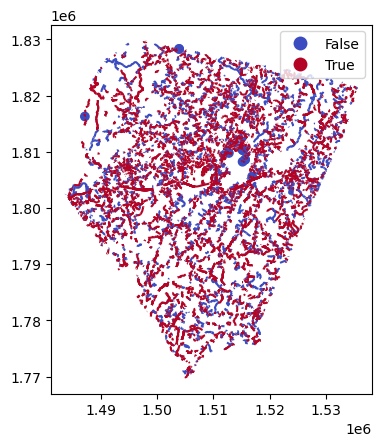

In [85]:
import matplotlib.pyplot as plt

old.plot(column='was_snapped', legend=True, cmap='coolwarm')
